In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your specific file path found in the input sidebar
df = pd.read_csv('/kaggle/input/datasets/mrunalsangshetti/netflix-movies/netflix_titles.csv')

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mrunalsangshetti/netflix-movies/netflix_titles.csv


show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64


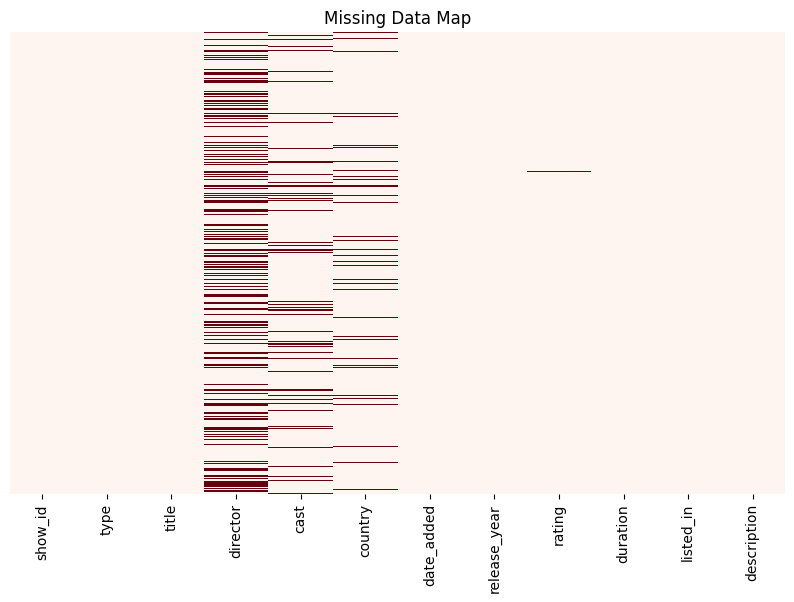

In [3]:

print(df.isnull().sum())

plt.figure(figsize=(10, 6))
# Using a 'magma' or 'rocket' palette looks great in dark-mode notebooks
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='Reds')
plt.title('Missing Data Map')
plt.show()

In [4]:
# Ensure date_added is in datetime format first
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# Create the missing columns
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()
df['day_added'] = df['date_added'].dt.day_name() # <--- This creates the column you're missing!

# Now run your Friday Night chart code again
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_data = df['day_added'].value_counts().reindex(day_order)

print("Columns created successfully! You can now run your visualizations.")

Columns created successfully! You can now run your visualizations.


In [5]:
import plotly.express as px


genres_expanded = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')


genre_counts = genres_expanded['listed_in'].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count'] # Explicitly naming columns to match px call

# 3. Take Top 15
genre_counts = genre_counts.head(15)

# 4. Create the Chart
fig = px.bar(genre_counts, 
             x='Count', 
             y='Genre', 
             orientation='h',
             title='Top 15 Most Popular Genres',
             template='plotly_dark',
             color='Count',
             color_continuous_scale='Reds')

# Improve layout
fig.update_layout(
    yaxis={'categoryorder':'total ascending'}, 
    showlegend=False,
    font=dict(family="Arial", size=12, color="white")
)

fig.show()

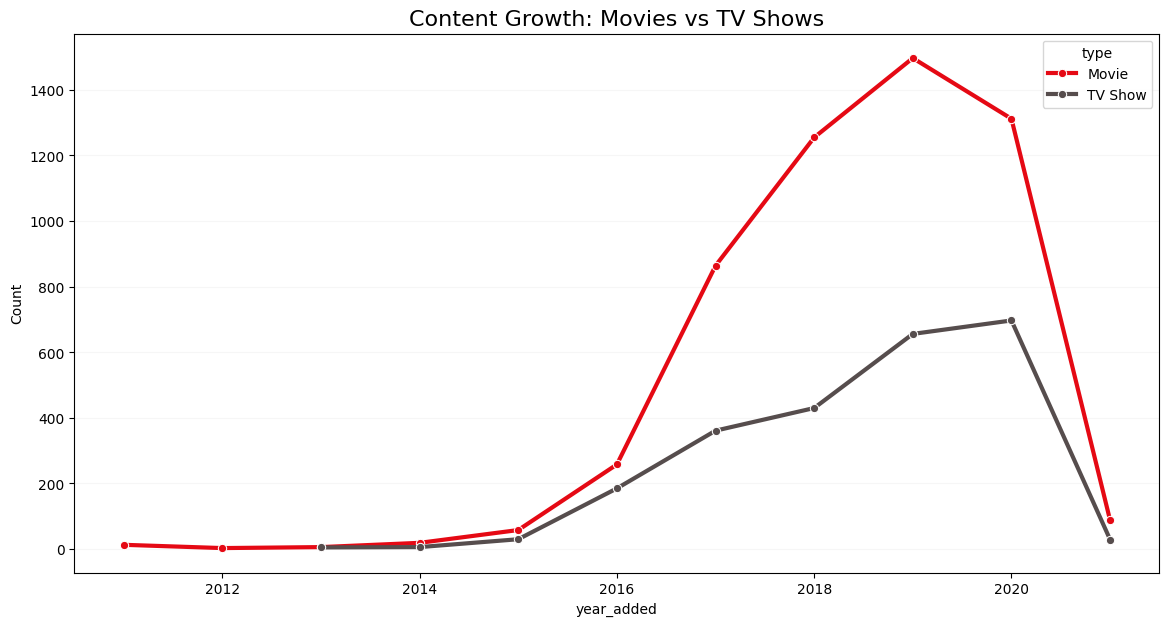

In [6]:
growth = df.groupby(['year_added', 'type']).size().reset_index(name='Count')
growth = growth[growth['year_added'] > 2010] # Focus on the modern era

plt.figure(figsize=(14, 7))
sns.lineplot(data=growth, x='year_added', y='Count', hue='type', palette=['#E50914', '#564d4d'], linewidth=3, marker='o')

plt.title('Content Growth: Movies vs TV Shows', fontsize=16)
plt.grid(axis='y', alpha=0.1)
plt.show()

/tmp/ipykernel_16/1834090275.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




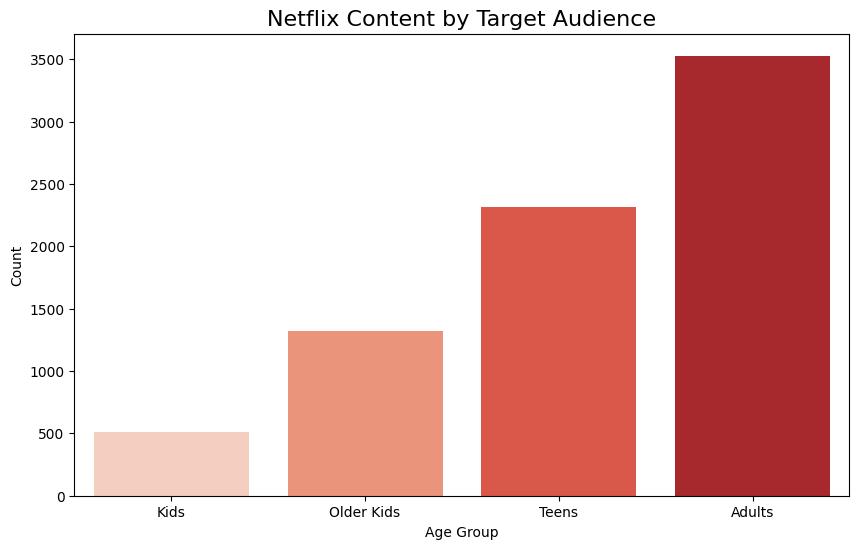

In [7]:
# 1. Map ratings to simpler categories
rating_map = {
    'TV-MA': 'Adults', 'R': 'Adults', 'PG-13': 'Teens', 
    'TV-14': 'Teens', 'TV-PG': 'Older Kids', 'PG': 'Older Kids', 
    'TV-Y7': 'Older Kids', 'TV-G': 'Kids', 'TV-Y': 'Kids', 'G': 'Kids'
}
df['target_ages'] = df['rating'].replace(rating_map)

# 2. Plot
plt.figure(figsize=(10, 6))
sns.countplot(x='target_ages', data=df, order=['Kids', 'Older Kids', 'Teens', 'Adults'], palette='Reds')
plt.title('Netflix Content by Target Audience', fontsize=16)
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

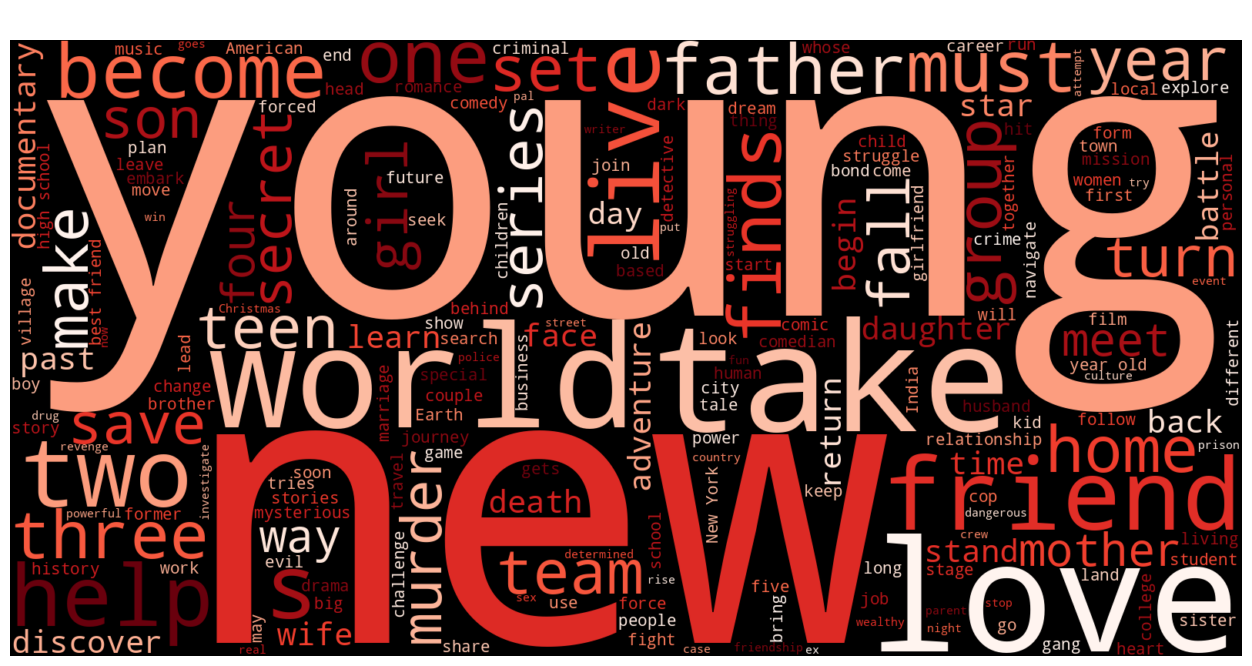

In [8]:
from wordcloud import WordCloud, STOPWORDS

# 1. Combine all descriptions into one giant string
text = " ".join(review for review in df.description.dropna())

# 2. Set stopwords (words like 'the', 'is', 'a' that we want to ignore)
stopwords = set(STOPWORDS)
stopwords.update(["life", "find", "family", "man", "woman"]) # Adding extra common words

# 3. Create the wordcloud
wordcloud = WordCloud(stopwords=stopwords, 
                      background_color="black", 
                      colormap="Reds", 
                      width=1600, height=800).generate(text)

# 4. Display
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Common Themes in Netflix Plot Summaries', fontsize=20, color='white')
plt.show()

In [9]:
# 1. Create a subset and ensure everything is a string
pairs = df.dropna(subset=['director', 'cast']).copy()

# 2. Extract pairs safely
director_actor_list = []

for _, row in pairs.iterrows():
    # We force the values to strings just in case a float slipped in
    d_val = str(row['director'])
    c_val = str(row['cast'])
    
    # Only split if they aren't the placeholder strings we made earlier
    if d_val != 'No Director' and c_val != 'No Cast':
        d_list = d_val.split(', ')
        c_list = c_val.split(', ')
        for d in d_list:
            for c in c_list:
                director_actor_list.append((d, c))

# 3. Create DataFrame and count
pair_df = pd.DataFrame(director_actor_list, columns=['Director', 'Actor'])
top_pairs = pair_df.value_counts().reset_index(name='Collaboration Count').head(10)

# 4. Display the results nicely
print("Top 10 Director-Actor Collaborations on Netflix:")
top_pairs

Top 10 Director-Actor Collaborations on Netflix:


,Director,Actor,Collaboration Count
0,S.S. Rajamouli,Nassar,7
1,S.S. Rajamouli,Anushka Shetty,7
2,S.S. Rajamouli,Prabhas,7
3,S.S. Rajamouli,Sathyaraj,7
4,S.S. Rajamouli,Ramya Krishnan,7
5,S.S. Rajamouli,Tamannaah Bhatia,7
6,S.S. Rajamouli,Rana Daggubati,7
7,Yılmaz Erdoğan,Yılmaz Erdoğan,7
8,David Dhawan,Anupam Kher,6
9,Cathy Garcia-Molina,Joross Gamboa,6


In [10]:
import plotly.express as px

# 1. Clean the country column (splitting "USA, India" into separate rows)
country_counts = df.assign(country=df['country'].str.split(', ')).explode('country')
country_counts = country_counts['country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']

# 2. Create the Choropleth Map
fig = px.choropleth(country_counts, 
                    locations="Country", 
                    locationmode='country names',
                    color="Count", 
                    hover_name="Country", 
                    title='Global Distribution of Netflix Content',
                    color_continuous_scale='Reds',
                    template='plotly_dark')

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Titles")
)

fig.show()

<>:3: SyntaxWarning:

invalid escape sequence '\d'

<>:3: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipykernel_16/4056125223.py:3: SyntaxWarning:

invalid escape sequence '\d'



<Figure size 1200x800 with 0 Axes>

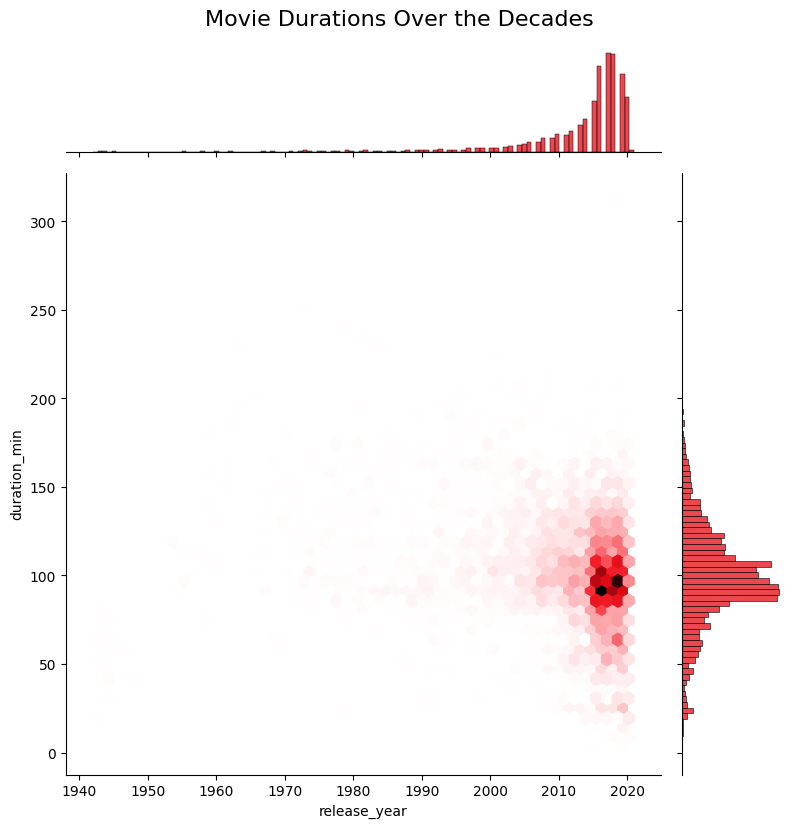

In [11]:
# Filter only movies and ensure duration is numeric
movies_only = df[df['type'] == 'Movie'].copy()
movies_only['duration_min'] = movies_only['duration'].str.extract('(\d+)').astype(float)

# Create a jointplot to see the density of movie lengths over years
plt.figure(figsize=(12, 8))
sns.jointplot(x='release_year', y='duration_min', data=movies_only, 
              kind="hex", color="#E50914", height=8)
plt.suptitle('Movie Durations Over the Decades', y=1.03, fontsize=16)
plt.show()